## Parte 3 - Aprendizaje supervisado con Dataset 1

Despues de hablar con el profesor, tomamos la decisión de utilizar el dataset del grupo 1, ya que los datos del dataset del grupo 10 presentaban inconsistencias.

Objetivo: usar las primeras columnas del dataset (`pm25`, `no2`, `trafico`, `viento`) para predecir las dos últimas columnas:

1. `alerta`: problema de clasificación.
2. `contaminacion`: problema de regresión.

### 0. Carga y revision del dataset

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# La ruta funciona si el notebook se ejecuta desde P3 o desde la raiz del proyecto.
ruta = Path("Grupo1.csv")
if not ruta.exists():
    ruta = Path("P3/Grupo1.csv")

df = pd.read_csv(ruta, sep=";")
df.head()

,pm25,no2,trafico,viento,contaminacion,alerta
0,68.52,80.76,67.72,4.19,166.85,True
1,45.27,27.18,37.02,2.84,76.44,False
2,73.58,31.84,46.65,2.57,146.36,False
3,NaN,58.60,65.08,2.23,160.68,False
4,31.45,53.54,71.93,NaN,116.55,False


In [2]:
variables_entrada = ["pm25", "no2", "trafico", "viento"]
objetivo_clasificacion = "alerta"
objetivo_regresion = "contaminacion"

# Convertimos la variable de clasificacion a 0/1.
df[objetivo_clasificacion] = df[objetivo_clasificacion].map({
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
})

print("Filas y columnas:", df.shape)
print("\nValores nulos por columna:")
print(df.isna().sum())

print("\nCantidad de ejemplos por clase:")
print(df[objetivo_clasificacion].value_counts(dropna=False))

df.describe()

Filas y columnas: (500, 6)

Valores nulos por columna:
pm25             5
no2              5
trafico          5
viento           5
contaminacion    5
alerta           5
dtype: int64

Cantidad de ejemplos por clase:
alerta
0.0    345
1.0    150
NaN      5
Name: count, dtype: int64


,pm25,no2,trafico,viento,contaminacion,alerta
count,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000
mean,53.113232,43.671697,61.696545,3.250727,140.793111,0.303030
std,23.398909,24.537984,23.310316,1.316734,40.736905,0.460033
min,-13.820000,-8.850000,-4.540000,0.320000,38.980000,0.000000
25%,38.590000,29.770000,47.170000,2.510000,115.850000,0.000000
50%,51.940000,41.110000,61.660000,3.090000,138.570000,0.000000
75%,66.670000,54.100000,74.345000,3.885000,164.195000,1.000000
max,144.910000,244.840000,148.530000,10.530000,293.850000,1.000000


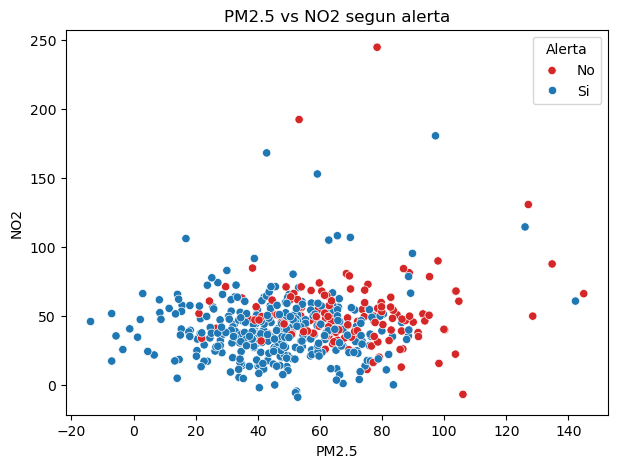

In [3]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="pm25",
    y="no2",
    hue="alerta",
    palette={0: "tab:blue", 1: "tab:red"},
)
plt.title("PM2.5 vs NO2 segun alerta")
plt.xlabel("PM2.5")
plt.ylabel("NO2")
plt.legend(title="Alerta", labels=["No", "Si"])
plt.show()

### 1. Problema de clasificacion: predecir `alerta`

Para la clasificacion usamos como entrada solo las variables `pm25`, `no2`, `trafico` y `viento`.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Eliminamos filas donde falta la clase objetivo.
datos_clasificacion = df.dropna(subset=[objetivo_clasificacion]).copy()

X = datos_clasificacion[variables_entrada]
y = datos_clasificacion[objetivo_clasificacion].astype(int)

# Rellenamos nulos de las variables de entrada con la mediana de cada columna.
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (346, 4)
Test: (149, 4)


In [5]:
def evaluar_clasificacion(nombre_modelo, y_real, y_pred):
    print(f"=== {nombre_modelo} ===")
    print(f"Accuracy: {accuracy_score(y_real, y_pred):.3f}")
    print("\nReporte de clasificacion:")
    print(classification_report(
        y_real,
        y_pred,
        target_names=["No alerta", "Alerta"],
        zero_division=0,
    ))

    matriz = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No alerta", "Alerta"],
        yticklabels=["No alerta", "Alerta"],
    )
    plt.title(f"Matriz de confusion - {nombre_modelo}")
    plt.xlabel("Prediccion")
    plt.ylabel("Valor real")
    plt.show()

=== Regresion Logistica ===
Accuracy: 0.819

Reporte de clasificacion:
              precision    recall  f1-score   support

   No alerta       0.83      0.92      0.88       104
      Alerta       0.76      0.58      0.66        45

    accuracy                           0.82       149
   macro avg       0.80      0.75      0.77       149
weighted avg       0.81      0.82      0.81       149



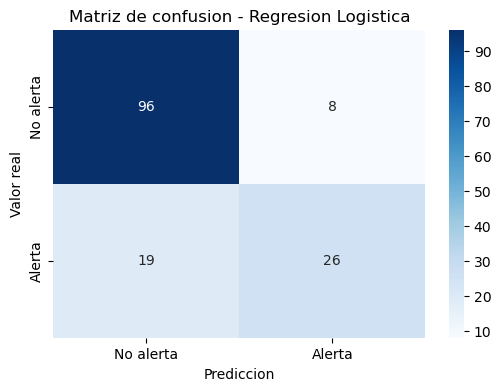

In [6]:
# Modelo 1: Regresion Logistica
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistico.fit(X_train, y_train)

y_pred_logistico = modelo_logistico.predict(X_test)
evaluar_clasificacion("Regresion Logistica", y_test, y_pred_logistico)

=== Arbol de Decision ===
Accuracy: 0.785

Reporte de clasificacion:
              precision    recall  f1-score   support

   No alerta       0.85      0.85      0.85       104
      Alerta       0.64      0.64      0.64        45

    accuracy                           0.79       149
   macro avg       0.75      0.75      0.75       149
weighted avg       0.79      0.79      0.79       149



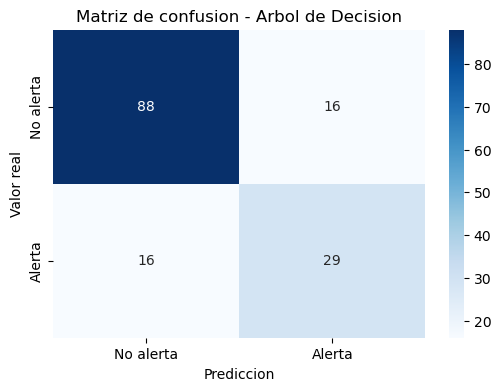

In [7]:
# Modelo 2: Arbol de Decision
modelo_arbol_clasificacion = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arbol_clasificacion.fit(X_train, y_train)

y_pred_arbol_clasificacion = modelo_arbol_clasificacion.predict(X_test)
evaluar_clasificacion("Arbol de Decision", y_test, y_pred_arbol_clasificacion)

### 2. Problema de regresion: predecir `contaminacion`

Para la regresion usamos la misma idea: las entradas son `pm25`, `no2`, `trafico` y `viento`, y la salida numerica es `contaminacion`.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Eliminamos filas donde falta el valor numerico que queremos predecir.
datos_regresion = df.dropna(subset=[objetivo_regresion]).copy()

X_reg = datos_regresion[variables_entrada]
y_reg = datos_regresion[objetivo_regresion]

# Rellenamos nulos de las variables de entrada con la mediana de cada columna.
X_reg = X_reg.fillna(X_reg.median())

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.30,
    random_state=42,
)

print("Train:", X_train_reg.shape)
print("Test:", X_test_reg.shape)

Train: (346, 4)
Test: (149, 4)


In [9]:
def evaluar_regresion(nombre_modelo, y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    print(f"=== {nombre_modelo} ===")
    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R2: {r2:.3f}")

In [10]:
# Modelo 1: Regresion Lineal.
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_reg, y_train_reg)

y_pred_lineal = modelo_lineal.predict(X_test_reg)
evaluar_regresion("Regresion Lineal", y_test_reg, y_pred_lineal)

print("\nIntercepto:", modelo_lineal.intercept_)
print("Coeficientes:")
for variable, coeficiente in zip(variables_entrada, modelo_lineal.coef_):
    print(f"{variable}: {coeficiente:.3f}")

=== Regresion Lineal ===
MSE: 514.214
RMSE: 22.676
MAE: 18.138
R2: 0.683

Intercepto: 28.087267516801674
Coeficientes:
pm25: 0.762
no2: 0.606
trafico: 0.883
viento: -2.986


In [11]:
# Modelo 2: Arbol de Decision para Regresion.
modelo_arbol_regresion = DecisionTreeRegressor(max_depth=4, random_state=42)
modelo_arbol_regresion.fit(X_train_reg, y_train_reg)

y_pred_arbol_regresion = modelo_arbol_regresion.predict(X_test_reg)
evaluar_regresion("Arbol de Decision para Regresion", y_test_reg, y_pred_arbol_regresion)

=== Arbol de Decision para Regresion ===
MSE: 902.239
RMSE: 30.037
MAE: 24.046
R2: 0.445


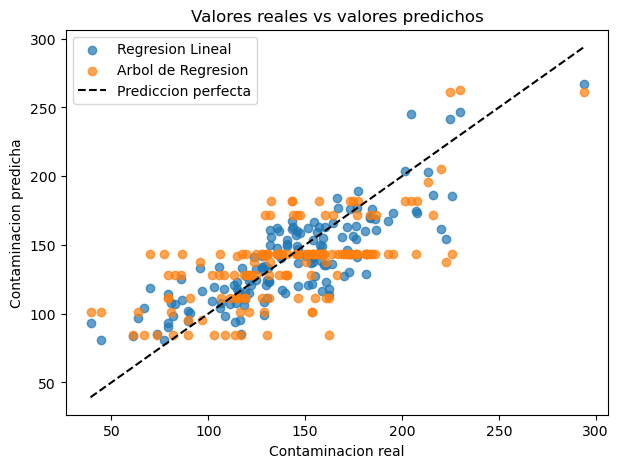

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_lineal, alpha=0.7, label="Regresion Lineal")
plt.scatter(y_test_reg, y_pred_arbol_regresion, alpha=0.7, label="Arbol de Regresion")

minimo = min(y_test_reg.min(), y_pred_lineal.min(), y_pred_arbol_regresion.min())
maximo = max(y_test_reg.max(), y_pred_lineal.max(), y_pred_arbol_regresion.max())
plt.plot([minimo, maximo], [minimo, maximo], "k--", label="Prediccion perfecta")

plt.title("Valores reales vs valores predichos")
plt.xlabel("Contaminacion real")
plt.ylabel("Contaminacion predicha")
plt.legend()
plt.show()

In [13]:
resultados_regresion = pd.DataFrame({
    "real": y_test_reg,
    "pred_lineal": y_pred_lineal,
    "pred_arbol": y_pred_arbol_regresion,
})

resultados_regresion.head(10)

,real,pred_lineal,pred_arbol
461,162.31,113.410027,111.583871
73,166.42,183.934199,127.775362
312,151.44,120.721118,143.661057
175,131.61,149.769551,137.812308
336,154.21,153.405884,143.661057
204,80.55,107.477104,101.022000
155,154.30,137.348728,143.661057
55,131.45,123.424935,127.775362
322,171.38,162.970290,143.661057
9,145.05,157.353130,143.661057


# Desarrollo análisis: